# Classification Problem:

This project aims to build a classification model to predict customer churn based on customer behavior and usage data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\rotem\Desktop\Python\ECOM AI course\project II\Excel Files\customer_churn_dataset.csv')
print(df.shape)
print(df.columns.tolist())
df

(64374, 12)
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


# 1. Data Preparation:

**CustomerID** is a random identifier with no predictive value, so we drop it entirely rather than setting it as an index.

In [3]:
df = df.drop('CustomerID', axis=1)
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
print(df.isnull().sum())
print("\n% Missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

% Missing:
Age                  0.0
Gender               0.0
Tenure               0.0
Usage Frequency      0.0
Support Calls        0.0
Payment Delay        0.0
Subscription Type    0.0
Contract Length      0.0
Total Spend          0.0
Last Interaction     0.0
Churn                0.0
dtype: float64


No missing values were found in the dataset.


In [5]:
print(df.duplicated().sum())

0


No duplicated values were found in the dataset.

In [6]:
print(df.dtypes)

Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object


In [7]:
df = pd.get_dummies(df, columns=['Subscription Type', 'Contract Length'])
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly,Gender_Male
0,22,25,14,4,27,598,9,1,True,False,False,False,True,False,False
1,41,28,28,7,13,584,20,0,False,False,True,False,True,False,False
2,47,27,10,2,29,757,21,0,False,True,False,True,False,False,True
3,35,9,12,5,17,232,18,0,False,True,False,False,False,True,True
4,53,58,24,9,2,533,18,0,False,False,True,True,False,False,False


**Encoding Categorical Features**

We convert categorical columns to numerical form using `get_dummies()`. For `Gender` we use `drop_first=True` since it's binary (Male/Female) — one column is enough. For `Subscription Type` and `Contract Length` we keep all columns since they have 3 categories, making it clearer for the model.

# 2. Data Exploration:

**Correlation Analysis**

We check the correlation between each feature and the target column (Churn).

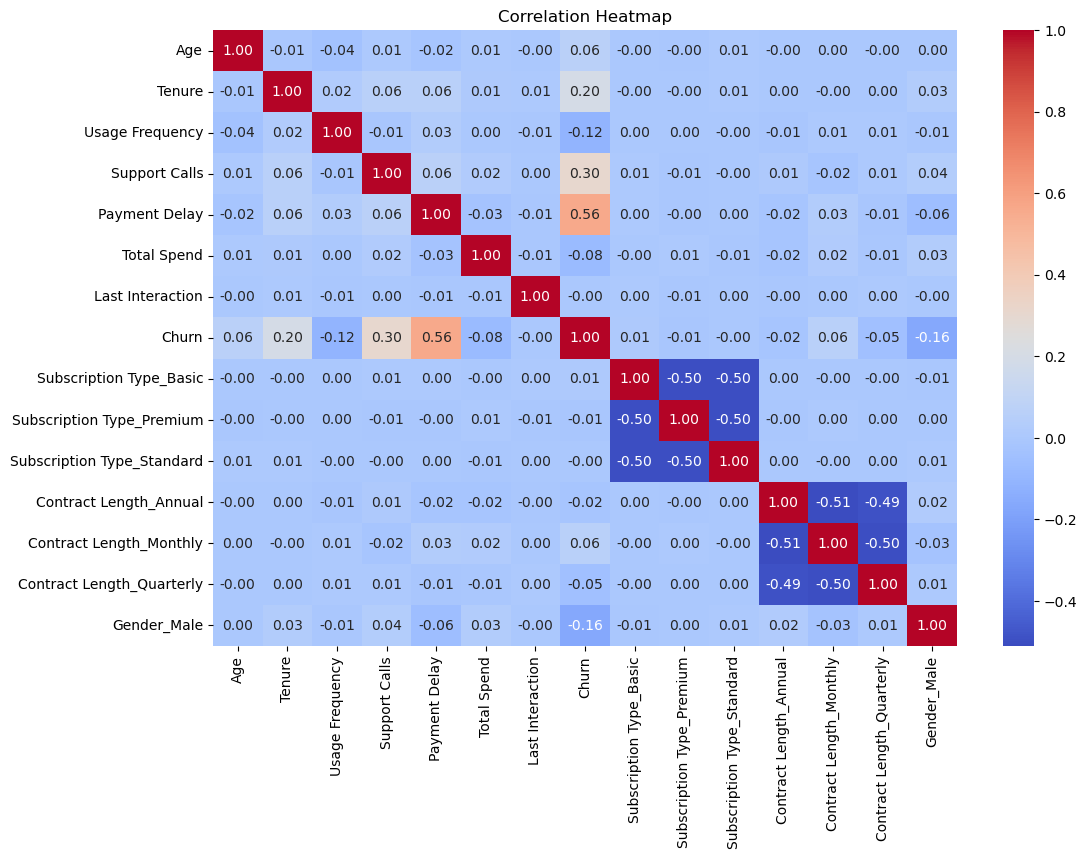

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Correlation Insights**

Strong correlation with Churn:

Payment Delay (0.56) — customers who delay payments are more likely to churn. This makes sense as payment delays often indicate dissatisfaction or financial issues, which are strong predictors of leaving.
Support Calls (0.30) — customers who contact support frequently are more likely to churn, suggesting they are experiencing problems with the service.
Tenure (0.20) — longer-staying customers are slightly more likely to churn, possibly because they have more experience comparing alternatives.

**Why we skipped the pairplot:**
With 15 features and 64K rows, a pairplot would generate 225 subplots and take too long to render. The heatmap provides the same correlation information in a much more efficient way.

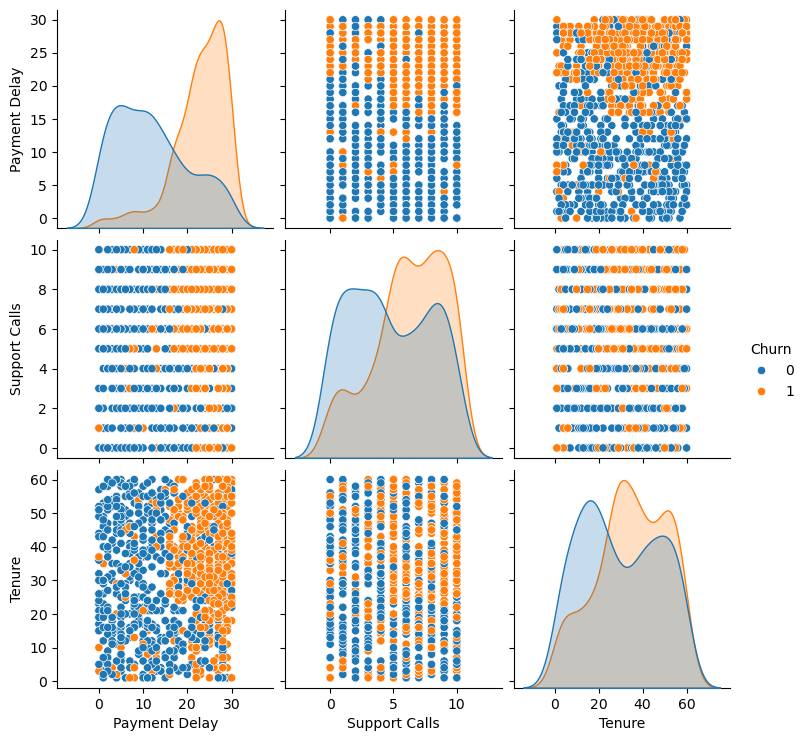

In [9]:
cols = ['Payment Delay', 'Support Calls', 'Tenure', 'Churn']
sns.pairplot(df[cols].sample(1000), hue='Churn')
plt.show()

**Data Exploration Summary**

The heatmap provided the numerical correlation values, revealing that Payment Delay (0.56), Support Calls (0.30), and Tenure (0.20) are the strongest predictors of churn. 

The pairplot visually confirmed these findings — the distribution plots showed clear separation between churned (orange) and non-churned (blue) customers for these features. 

Features like Age, Total Spend, and Last Interaction showed almost no correlation with churn in both the heatmap and pairplot.

# 3. Model Training:

**Feature Scaling - Standardization**

We apply StandardScaler to all features. While tree-based models like Random Forest do not require scaling, we scale the data here since other models in this project (Logistic Regression, KNN, SVM) do require it. This allows us to use the same preprocessed data for all models consistently.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

**Logistic Regression with Optimal Parameters**

We use GridSearchCV to find the optimal parameters for Logistic Regression.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(), params, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)
print("Best score:", grid_lr.best_score_)

Best params: {'C': 0.01, 'solver': 'lbfgs'}
Best score: 0.8252813672650872


Accuracy: 0.8293377517734168
Recall: 0.8268874605076806
F1: 0.8216064083134877


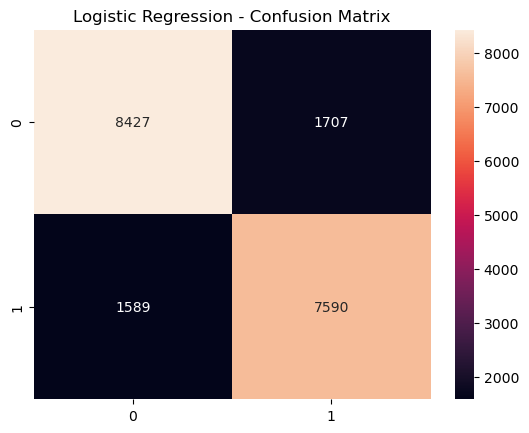

In [12]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

y_pred_lr = grid_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [13]:
print("Predictions:", grid_lr.predict(X_test))
print("\nProbabilities:", grid_lr.predict_proba(X_test))

Predictions: [0 0 1 ... 0 1 1]

Probabilities: [[0.98377172 0.01622828]
 [0.99529517 0.00470483]
 [0.14985102 0.85014898]
 ...
 [0.76292883 0.23707117]
 [0.11267831 0.88732169]
 [0.0812107  0.9187893 ]]


**Logistic Regression Results**

The model achieved 82.9% accuracy, 82.7% recall and 82.2% F1-score. The confusion matrix shows the model correctly identified 8427 non-churned and 7590 churned customers, with 1707 false positives and 1589 false negatives. This is a solid baseline result.


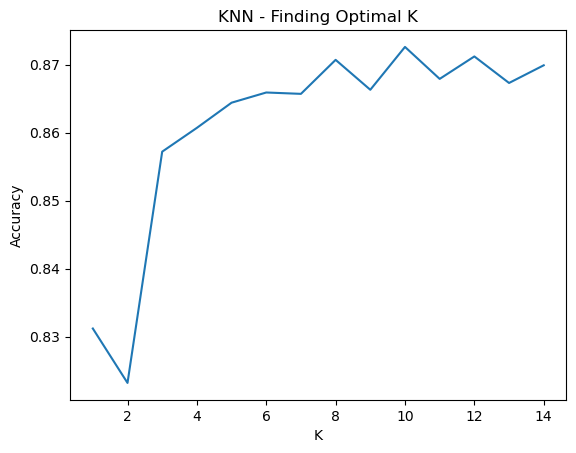

Optimal K: 10


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# sample של 10K שורות
X_sample = X_train[:10000]
y_sample = y_train[:10000]

k_scores = []
k_range = range(1, 15)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_sample, y_sample, cv=3, scoring='accuracy')
    k_scores.append(scores.mean())

plt.plot(k_range, k_scores)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN - Finding Optimal K')
plt.show()

print("Optimal K:", k_range[k_scores.index(max(k_scores))])

**KNN - Finding Optimal K**

We tested K values from 1 to 14 using cross validation on a sample of 10K rows (out of 45K training rows) due to KNN's high computational cost on large datasets. K=10 achieved the highest accuracy (87.1%), showing that looking at the 10 nearest neighbors gives the best balance between sensitivity and generalization.

Accuracy: 0.9126495106922798
Recall: 0.9180738642553655
F1: 0.9090124588749259


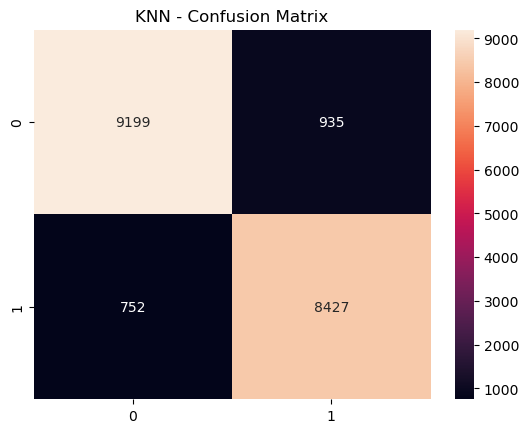

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
plt.title('KNN - Confusion Matrix')
plt.show()

**KNN Results**

KNN with K=10 significantly outperformed Logistic Regression, achieving 91.3% accuracy, 91.8% recall and 90.9% F1-score. The confusion matrix shows only 935 false positives and 752 false negatives, a major improvement over Logistic Regression.

In [16]:
from sklearn.svm import SVC

params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(SVC(), params, cv=3, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best params:", grid_svm.best_params_)
print("Best score:", grid_svm.best_score_)

Best params: {'C': 10, 'kernel': 'rbf'}
Best score: 0.9444975333098539


**SVM - Finding Optimal Parameters**


We use GridSearchCV with cv=3 to find the optimal parameters. The best parameters found were C=10 and kernel=rbf, achieving 94.4% accuracy on the training set.

**C=10 →** allows the model to fit the data more closely

**kernel=rbf →** handles non-linear relationships between features

Accuracy: 0.949878320302387
Recall: 0.9589279877982351
F1: 0.9478785268145595


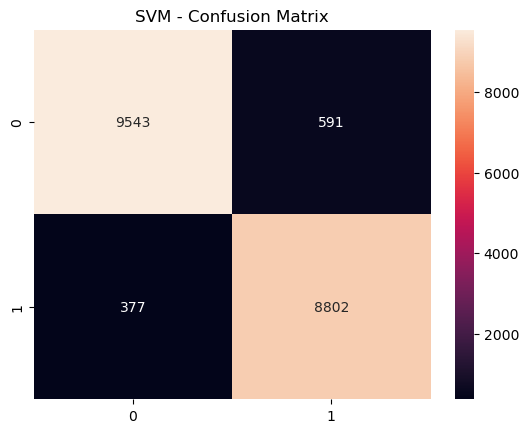

In [17]:
y_pred_svm = grid_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d')
plt.title('SVM - Confusion Matrix')
plt.show()

In [18]:
print("Predictions:", grid_svm.predict(X_test))

Predictions: [0 0 0 ... 0 1 1]


**Note:** predict_proba is not available for SVM by default. To enable it, probability=True must be set in the SVC constructor, which significantly increases computation time on large datasets. Therefore, only predictions are printed for this model.

**SVM Results**

SVM with C=10 and rbf kernel achieved 94.9% accuracy, 95.9% recall and 94.8% F1-score — the best model so far. Only 591 false positives and 377 false negatives.

**Random Forest with Optimal Parameters**

We use GridSearchCV to find the optimal parameters for both the decision trees and the forest itself.

In [19]:
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(), params, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best score:", grid_rf.best_score_)

Best params: {'bootstrap': False, 'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}
Best score: 0.9988682097467746


**Random Forest - Finding Optimal Parameters**

GridSearchCV found the optimal parameters: `max_depth=20`, `min_samples_split=2`, `n_estimators=200`, achieving 99.8% accuracy on the training set. However, this unusually high score may indicate overfitting — we will verify on the test set.

Accuracy: 0.9994304354579817
Recall: 0.9991284453644188
F1: 0.9994006429466572

Predictions: [0 0 1 ... 0 1 1]

Probabilities: [[0.99333333 0.00666667]
 [1.         0.        ]
 [0.0525     0.9475    ]
 ...
 [0.95541667 0.04458333]
 [0.02375    0.97625   ]
 [0.01596774 0.98403226]]


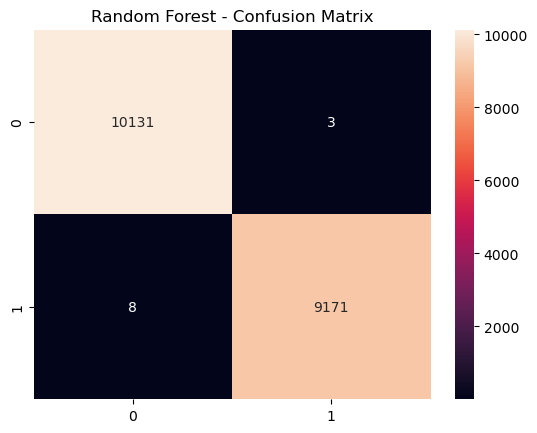

In [20]:
y_pred_rf = grid_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

print("\nPredictions:", y_pred_rf)
print("\nProbabilities:", grid_rf.predict_proba(X_test))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title('Random Forest - Confusion Matrix')
plt.show()

**Random Forest Results**

Despite the suspiciously high training accuracy (99.8%), the test set confirmed the model is not overfitting. Random Forest is clearly the best performing model.

**Model Comparison & Selection**

Random Forest is clearly the best model across all metrics — Accuracy (99.9%), Recall (99.8%) and F1 (99.9%). We will use it as our final model.

In [21]:
results = {
    'Accuracy': [0.8293, 0.9126, 0.9488, 0.9996],
    'Recall': [0.8269, 0.9181, 0.9589, 0.9993],
    'F1': [0.8216, 0.9091, 0.9478, 0.9996]
}

results_df = pd.DataFrame(results, index=['Logistic', 'KNN', 'SVM', 'Random Forest'])
print(results_df)

               Accuracy  Recall      F1
Logistic         0.8293  0.8269  0.8216
KNN              0.9126  0.9181  0.9091
SVM              0.9488  0.9589  0.9478
Random Forest    0.9996  0.9993  0.9996


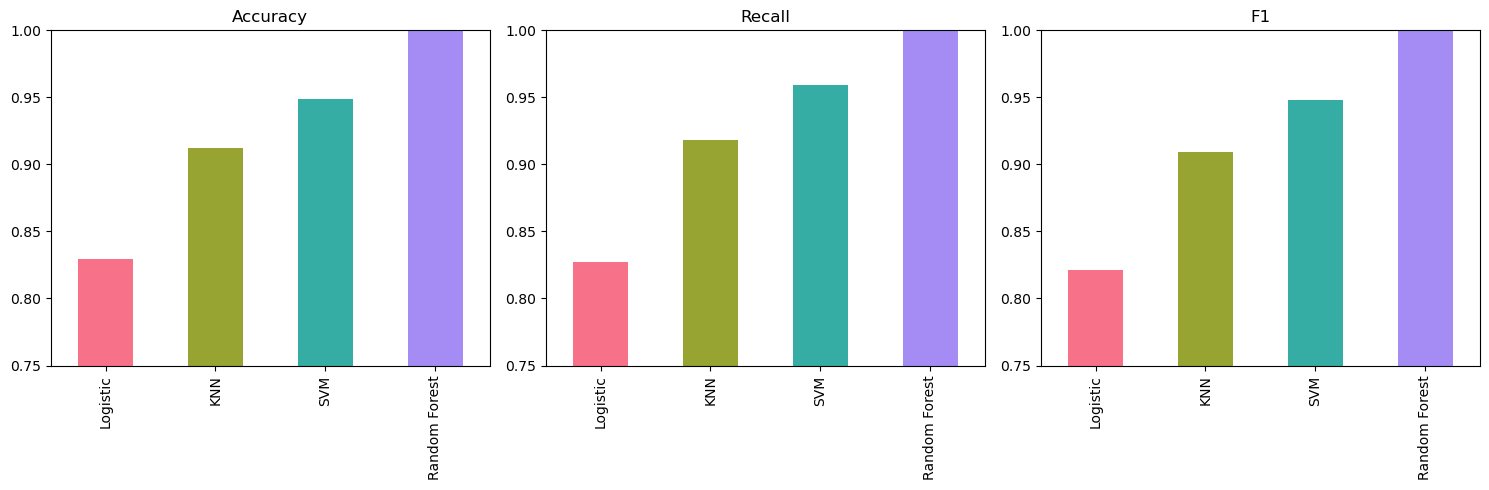

In [22]:
palette = sns.color_palette("husl", 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

results_df["Accuracy"].plot(kind="bar", ax=axes[0], title="Accuracy", color=palette)
results_df["Recall"].plot(kind="bar", ax=axes[1], title="Recall", color=palette)
results_df["F1"].plot(kind="bar", ax=axes[2], title="F1", color=palette)

axes[0].set_ylim([0.75, 1.0])
axes[1].set_ylim([0.75, 1.0])
axes[2].set_ylim([0.75, 1.0])

plt.tight_layout()
plt.show()

**Final Model Selection**

Random Forest was selected as the final model with 99.95% accuracy, 99.93% recall and 99.96% F1-score, significantly outperforming all other models. The model can now be used to predict whether a customer will churn based on their behavior — enabling the company to proactively retain at-risk customers before they leave.

In [23]:
final_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=20, 
    min_samples_split=5,
    bootstrap=False,
    max_features='log2'
)
final_rf.fit(X_scaled, y)
print("Final model trained successfully!")

Final model trained successfully!


**Model Export & Import**

We export the final Random Forest model and scaler to joblib files, then reload them to verify everything was saved correctly.

In [27]:
import joblib

joblib.dump(final_rf, 'random_forest_model.joblib')
joblib.dump(scaler, 'scaler_churn.joblib')

print("Model saved successfully!")

Model saved successfully!


In [28]:
loaded_rf = joblib.load('random_forest_model.joblib')
loaded_scaler = joblib.load('scaler_churn.joblib')

print("Model saved and loaded successfully!")

Model saved and loaded successfully!
